<b><center>Department of Mathematics</center></b>
<b><center>College of Arts and Sciences, Howard University</center></b>
<b><center>Math 014 (02) Introduction to Data Science-Honors (Spring 2025)</center></b> 
<b><center>Project 2</center></b>

<b>Student Name:</b> Jessica Ibegwam
<br>
<b>Student Id:</b> 003100529 <br> <b>Due date:</b> 04-18-2025
<br>



# The Analysis of the Infectiousness of Norovirus Induced Emesis

## Introduction
Right now, there is a Norovirus outbreak that affects hundreds of Americans. The Norovirus is known as the stomach flu, which initiates symptoms such as vomiting, diarrhea, and nausea. The Norovirus is a very resistant virus that can survive in many environments. It is one of the 0.01% of germs that hand sanitizers can not kill, which is why hand washing is vital for disease prevention. The Norovirus can be spread through direct contact with bodily fluids or contaimnated sources. This data focuses on emesis, also known as vomiting, from a Norovirus infection. The dataset explores four different studies with their own subjects who were sick with the virus. Each subject provided their own sample of vomit. In the studies, the time, volume, titer, and pH of the vomit were recorded. The titer of the vomit calculates the viral concentration of the Norovirus. This was used to evaluate the risk of viral transmission from a person's vomit. The dataset represents three strains of the Norovirus, which were GI.1 Norwalk virus, GII.2 Snow Mountain virus, and the GII.1 Hawaii virus. 

### Reference
Kirby, A. E., Streby, A., & Moe, C. L. (2016). Vomiting as a Symptom and Transmission Risk in Norovirus Illness: Evidence from Human Challenge Studies.         <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;*PloS one, 11*(4), e0143759. https://doi.org/10.1371/journal.pone.0143759

In [5]:
import pandas as pd
import numpy as np
#Imports both pandas and numpy
import matplotlib.pyplot as plt
import seaborn as sns
#Imports both matplot and seaborn for data visualization

### SECTION I: DATASET OVERVIEW AND STRUCTURE (10 POINTS)

In [7]:
df= pd.read_csv('Emesis_Norovirus.csv')
df
#The command reads and calls the dataset

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26,359,ND,3.5
1,1,4,2,27,70,3.96E+04,2
2,1,4,3,30,173,ND,3.5
3,1,4,4,30.5,126,4.81E+02,4
4,1,4,5,34.5,336,8.10E+04,2.5
...,...,...,...,...,...,...,...
58,4,1,9,.,.,3.20E+04,8
59,4,2,1,26.3,749,ND,2.5
60,4,2,2,27.3,248,7.17E+02,2.5
61,4,2,3,28.3,112,4.63E+02,4.5


In [8]:
print("Shape of the data:", df.shape) #This list the numbers of rows and columns (respectively) in the dataset
print("columns name:",  df.columns) #This list the names of the columns

Shape of the data: (63, 7)
columns name: Index(['Study', 'Subject', 'Sample', 'time', 'volume', 'titer', 'pH'], dtype='object')


In [9]:
df.head() #Shows the first 5 data rows

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26,359,ND,3.5
1,1,4,2,27,70,3.96E+04,2
2,1,4,3,30,173,ND,3.5
3,1,4,4,30.5,126,4.81E+02,4
4,1,4,5,34.5,336,8.10E+04,2.5


In [10]:
df.tail() #Shows the Last five data rows

,Study,Subject,Sample,time,volume,titer,pH
58,4,1,9,.,.,3.20E+04,8
59,4,2,1,26.3,749,ND,2.5
60,4,2,2,27.3,248,7.17E+02,2.5
61,4,2,3,28.3,112,4.63E+02,4.5
62,4,2,4,39.2,330,ND,3.5


In [11]:
df.info()
#Provides general information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Study    63 non-null     int64 
 1   Subject  63 non-null     int64 
 2   Sample   63 non-null     int64 
 3   time     63 non-null     object
 4   volume   63 non-null     object
 5   titer    63 non-null     object
 6   pH       63 non-null     object
dtypes: int64(3), object(4)
memory usage: 3.6+ KB


According to the info, the numerical data (time, volume,  titer and pH) columns were typed as objects. While the categorical data (Study, Subject, and Sample) were typed as integers. I plan to reverse this when I clean the data. However, the titer have some categorical data, such as ND (Non-detectable). I plan to replace ND with 0 instead, to show that no viral concentrations were detected. 

In [13]:
df.isnull().sum() #Provides the amount of missing values in each column

Study      0
Subject    0
Sample     0
time       0
volume     0
titer      0
pH         0
dtype: int64

This may or may not be accurate until the data has been reorganized.

## SECTION II: DATA CLEANING & INDEXING (10 POINTS)

### Rearranging and Fixing the Dataset
<li>I will need to change the data types of the columns to before fixing any missing values</li>
<li>First, I need to find all "." data, and replace it with NaN. According to the notes of the dataset, "." indiactes a missing value</li>
<li>Next, I will replace all the ND data under titer to "0.0"</li>
<li>Then, I will convert the numerical data from strings to floats, and convert the categorical data from integers to strings</li>

In [17]:
df_rearr=df.copy() #Copying the dataframe into a new variable just in case I make any errors

#### Replacing " ." with NaN
<li>Strings had to be used, since the titer data was typed as an object</li>

In [19]:
df_rearr.replace(".", np.nan, inplace=True) #This would replace all the "." with NaN

In [20]:
df_rearr #All the "." in the numerical data should be replaced with NaN

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26,359,ND,3.5
1,1,4,2,27,70,3.96E+04,2
2,1,4,3,30,173,ND,3.5
3,1,4,4,30.5,126,4.81E+02,4
4,1,4,5,34.5,336,8.10E+04,2.5
...,...,...,...,...,...,...,...
58,4,1,9,NaN,NaN,3.20E+04,8
59,4,2,1,26.3,749,ND,2.5
60,4,2,2,27.3,248,7.17E+02,2.5
61,4,2,3,28.3,112,4.63E+02,4.5


#### Replacing "ND" with "0.0"
<li>Strings had to be used, since the titer data was typed as an object</li>

In [22]:
df_rearr.replace("ND","0.0" , inplace=True) #Replaces the ND acronym with 0

In [23]:
df_rearr #All the Non-Detectable (ND) data were converted into 0. This adheres the fact that ND meant that no concentration of viruses were detected.

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26,359,0.0,3.5
1,1,4,2,27,70,3.96E+04,2
2,1,4,3,30,173,0.0,3.5
3,1,4,4,30.5,126,4.81E+02,4
4,1,4,5,34.5,336,8.10E+04,2.5
...,...,...,...,...,...,...,...
58,4,1,9,NaN,NaN,3.20E+04,8
59,4,2,1,26.3,749,0.0,2.5
60,4,2,2,27.3,248,7.17E+02,2.5
61,4,2,3,28.3,112,4.63E+02,4.5


#### Converting the Numerical Data From Strings to Booleans

In [25]:
numerical_data= ['time','volume','titer', 'pH']
df_rearr[numerical_data] = df_rearr[numerical_data].astype(float)
#This changes the strings into float for all the numerical data. 

In [26]:
df_rearr

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26.0,359.0,0.0,3.5
1,1,4,2,27.0,70.0,39600.0,2.0
2,1,4,3,30.0,173.0,0.0,3.5
3,1,4,4,30.5,126.0,481.0,4.0
4,1,4,5,34.5,336.0,81000.0,2.5
...,...,...,...,...,...,...,...
58,4,1,9,NaN,NaN,32000.0,8.0
59,4,2,1,26.3,749.0,0.0,2.5
60,4,2,2,27.3,248.0,717.0,2.5
61,4,2,3,28.3,112.0,463.0,4.5


#### Converting the Categorical Data From Integers to Floats

In [28]:
categorical_data =['Study', 'Subject', 'Sample']
df_rearr[categorical_data] = df_rearr[categorical_data].astype(str) #This converts the integers into strings for the categorical columns


In [29]:
df_rearr

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26.0,359.0,0.0,3.5
1,1,4,2,27.0,70.0,39600.0,2.0
2,1,4,3,30.0,173.0,0.0,3.5
3,1,4,4,30.5,126.0,481.0,4.0
4,1,4,5,34.5,336.0,81000.0,2.5
...,...,...,...,...,...,...,...
58,4,1,9,NaN,NaN,32000.0,8.0
59,4,2,1,26.3,749.0,0.0,2.5
60,4,2,2,27.3,248.0,717.0,2.5
61,4,2,3,28.3,112.0,463.0,4.5


In [30]:
df_rearr.info() #All categorical data is labeled object, and all numerical data are now labeled float.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Study    63 non-null     object 
 1   Subject  63 non-null     object 
 2   Sample   63 non-null     object 
 3   time     60 non-null     float64
 4   volume   52 non-null     float64
 5   titer    57 non-null     float64
 6   pH       58 non-null     float64
dtypes: float64(4), object(3)
memory usage: 3.6+ KB


### Cleaning Data

#### Now, I can check for missing values in the data set.


In [32]:
df_rearr.isnull().sum() #Checks for the total number of missing values in each column

Study       0
Subject     0
Sample      0
time        3
volume     11
titer       6
pH          5
dtype: int64

I plan to replace the missing values by the average of each other their column. Too much signficant data would be lost, if any of the missing value rows were dropped.

In [34]:
df_clean=df_rearr.copy()# copies the rearranged dataframe into a new variable for missing value cleaning

In [35]:
df_clean

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26.0,359.0,0.0,3.5
1,1,4,2,27.0,70.0,39600.0,2.0
2,1,4,3,30.0,173.0,0.0,3.5
3,1,4,4,30.5,126.0,481.0,4.0
4,1,4,5,34.5,336.0,81000.0,2.5
...,...,...,...,...,...,...,...
58,4,1,9,NaN,NaN,32000.0,8.0
59,4,2,1,26.3,749.0,0.0,2.5
60,4,2,2,27.3,248.0,717.0,2.5
61,4,2,3,28.3,112.0,463.0,4.5


In [36]:
df_clean['time']=df_clean['time'].fillna(df_clean['time'].mean()) 
df_clean['volume']=df_clean['volume'].fillna(df_clean['volume'].mean()) 
df_clean['titer']=df_clean['titer'].fillna(df_clean['titer'].mean()) 
df_clean['pH']=df_clean['pH'].fillna(df_clean['pH'].mean()) 
#The missing values were replaced by the averages of their respective columns.

In [37]:
df_clean

,Study,Subject,Sample,time,volume,titer,pH
0,1,4,1,26.00,359.000000,0.0,3.5
1,1,4,2,27.00,70.000000,39600.0,2.0
2,1,4,3,30.00,173.000000,0.0,3.5
3,1,4,4,30.50,126.000000,481.0,4.0
4,1,4,5,34.50,336.000000,81000.0,2.5
...,...,...,...,...,...,...,...
58,4,1,9,34.45,270.019231,32000.0,8.0
59,4,2,1,26.30,749.000000,0.0,2.5
60,4,2,2,27.30,248.000000,717.0,2.5
61,4,2,3,28.30,112.000000,463.0,4.5


In [38]:
df_clean.isnull().sum() #There should be zeros for each column

Study      0
Subject    0
Sample     0
time       0
volume     0
titer      0
pH         0
dtype: int64

In [39]:
df_clean.to_csv("Emesis_Norovirus_Clean.csv") #The cleaned dataset copied and saved in the folder

### I will provide two examples of DataFrame filtering using logical conditions 
<li>I will filter the dataset by the sample ID and its titer and pH</li>
<li>Then I will filter the dataset by the subject ID, volume, and titer.</li>

#### The pH and Titer of the Samples

In [42]:
viral_sample = df_clean[['Sample', 'titer', 'pH']] #Filters and stores these columns into a variable
viral_sample

,Sample,titer,pH
0,1,0.0,3.5
1,2,39600.0,2.0
2,3,0.0,3.5
3,4,481.0,4.0
4,5,81000.0,2.5
...,...,...,...
58,9,32000.0,8.0
59,1,0.0,2.5
60,2,717.0,2.5
61,3,463.0,4.5


The table above shows the viral concentration and pH of the sample. With this filtered table, I can analyze how infectious the sample is with the titer, and the presence of the norovirus GII.2 strain with the pH. 

### The Subject's Vomit and Titer production

In [45]:
titer_overzero = df_clean[(df_clean["titer"] > 0.0 ) & (df_clean["Subject"] ) & (df_clean['pH']) ]
subject_production= titer_overzero[['Subject', 'volume', 'titer']] 
#Filters the columns, but this time it would show only titers that are greater than 0. 

In [46]:
subject_production

,Subject,volume,titer
1,4,70.000000,3.960000e+04
3,4,126.000000,4.810000e+02
4,4,336.000000,8.100000e+04
5,4,139.000000,5.210000e+05
6,4,129.000000,1.330000e+06
11,40,36.000000,1.040000e+03
12,54,392.000000,1.620000e+04
13,54,193.000000,6.770000e+05
14,54,168.000000,5.380000e+05
15,54,114.000000,2.620000e+06


Here, I filtered the dataset to show only titer values greater than 0. Then, I filtered the dataset again to show only the subjects, volume, and titer. Using the filtered data, I can analyzed how much vomit each subject produced, and how infectious that vomit was.

## SECTION III: DESCRIPTIVE STATISTICS

#### Using .describe() on the time, volume, titer, and pH columns

In [50]:
time_volume_titer_ph=['time', 'volume', 'titer','pH']
df_clean[time_volume_titer_ph].describe()
#The statistics summary for each column were filtered and called

,time,volume,titer,pH
count,63.000000,63.000000,6.300000e+01,63.000000
mean,34.450000,270.019231,4.004661e+05,4.077586
std,10.817377,218.642328,8.514846e+05,1.861758
min,20.200000,6.000000,0.000000e+00,2.000000
25%,27.600000,113.000000,3.270000e+02,2.750000
50%,31.600000,232.000000,2.250000e+04,3.500000
75%,38.300000,333.000000,4.004661e+05,4.500000
max,90.300000,960.000000,4.990000e+06,9.000000


1. Titer is the only numerical column with a zero value.
2. There is a data point where a subject produced almost a liter of vomit.
3. A pH of 9 was the highest recorded pH. This seems weird since stomach acids (and vomits) tend to be very acidic (<6).
4. For the volume, the standard deviation is very high. Therefore, the data is more spread out compared to the other columns. 

### Using .value_counts() to analyze Subject and Samples

In [53]:
df_clean[["Subject","Sample"]].value_counts()
#The amount of unique values of the subject and sample columns were counted

Subject  Sample
2        1         3
         4         3
         3         3
         2         3
12       1         2
4        3         2
         2         2
         1         2
3        1         2
13       2         2
         1         2
12       2         2
1        1         2
11       2         1
1        5         1
7        2         1
         1         1
54       4         1
         3         1
         2         1
         1         1
40       2         1
         1         1
4        7         1
         6         1
         5         1
         4         1
1        3         1
         4         1
36       1         1
11       1         1
34       1         1
1        6         1
         7         1
         8         1
         9         1
         2         1
15       1         1
13       5         1
         4         1
         3         1
10       1         1
         2         1
12       3         1
10       3         1
8        1         1
Name: count, dtype

It seems that most of the data belongs to subjects (AKA patients)2 and 4. Patient 2 had four samples labeles 1-4. Patient 4 had three samples labeled 1-3. Their samples seems to appear frequently compared to others. Maybe these patients were apart of more extensive clinical resesearch as compared to others. 

### Grouping the averages of Titer and pH by Studies
<li>This was done to see the overall results from each Study that was implemented into the dataset</li>

In [56]:
study_results= df_clean.groupby('Study')[['titer', 'pH']].mean()
study_results
#These columns were grouped by Study and would show their averages for their respective Study.

,titer,pH
Study,,
1,364020.062500,3.250000
2,802762.197160,3.860837
3,191717.746289,3.716180
4,4208.384615,5.807692


In [57]:
study_result1= df_clean.groupby('Study')[['titer', 'pH']].count()
study_result1 
#These columns were grouped by Study and would show their value counts for their respective Study.

,titer,pH
Study,,
1,16,16
2,21,21
3,13,13
4,13,13


Studies 1-4 show variance in the titer results. However, studies 2 and 3 have close averages for the pH. Study 1 pH average is a little less, but somewhat close. Study 4 has the highest pH average, and the lowest titer (virus concentration). This could indicate that noroviruses do not drive as well in less acidic environments. Study 2 has the highest titer concentration out of all of the studies. However, Study 2 also has the most amount of data, which could contribute to that. Furthermore, it seems that the patterns from the dataset would be heavily influenced by Study 2.

### Grouping the means of pH, time, and volume by the titer
<li>This was done to observe any variables that could influence the titer concentration</li>

In [60]:
titer_var= df_clean.groupby('titer')[['time', 'volume', 'pH']].mean()
titer_var
#These columns were grouped by titer and would show their averages for each unique titer value.

,time,volume,pH
titer,,,
0.000000e+00,35.366667,381.401282,2.933333
1.910000e+02,31.200000,270.019231,8.000000
4.630000e+02,28.300000,112.000000,4.500000
4.810000e+02,30.500000,126.000000,4.000000
5.500000e+02,34.450000,270.019231,9.000000
6.980000e+02,36.100000,270.019231,8.500000
7.170000e+02,27.300000,248.000000,2.500000
1.040000e+03,38.500000,36.000000,3.000000
1.360000e+03,90.300000,16.000000,3.500000


This grouping provided some interesting results. My claim from earlier grouping was disproved here. It seems that the samples with the highest titers all had pH values closer to 5.5. This also proved that Study 4's data might not have a strong effect on the entirety of the dataset. Furthermore, it does not seem that time or volume has a significant correlation on the titer data. 

### Grouping Vomiting and Time by Subject
<li>This is used to study the amount and length of vomiting for each Norovirus patient </li>

In [63]:
emesis= df_clean.groupby('Subject')[['time', 'volume']].mean()
emesis
#These columns were grouped by Subject and would show their averages for their respective Subject.

,time,volume
Subject,,
1,31.415000,270.019231
10,27.866667,86.666667
11,25.950000,752.000000
12,40.440000,399.400000
13,46.857143,207.285714
15,55.000000,386.000000
2,27.575000,239.250000
3,30.900000,525.009615
34,50.500000,140.000000


In [64]:
emesis_max= df_clean.groupby('Subject')[['time', 'volume']].max()
emesis_max
#Shows the max of the time and volume by their respective Subject 

,time,volume
Subject,,
1,36.1,270.019231
10,29.0,101.000000
11,28.1,799.000000
12,45.2,960.000000
13,90.3,560.000000
15,55.0,386.000000
2,39.2,749.000000
3,34.1,780.000000
34,50.5,140.000000


The smallest amount of vomit that was recorded was by Subhect 40 with the average of  with 45 mL of vomit. While the highest average vomit volume recorded was by subject 11 was 752. mL. The highest amount of volume ever recorded was 960 mL. That is almost 1 L of vomit. 

## SECTION IV: OBSERVATIONS & QUESTIONS 

1. From the descriptive analysis, it was found that there could be a relationship between the pH and the titer of the vomit. It seems that the highest titer is usually accompanied by a pH of 5-5.5. Furthermore, the titer data and pH data may be heavily influenced by the results of Study 2. Therefore, it would be safer to evaluate the data in its entirety, and not by each Study. Another finding was that a lot of the Subjects in the dataset produced high volumes of vomit. Furthermore, one of the highest amounts of vomit was 960 mL, which is close to 1 L. The stomach holds about 1.5 L of food and fluids. It is clear that the norovirus contributes to high amounts of vomit in episodes that can last up to 90 seconds! Norovirus is a serious gastrointestinal disease that can make a patient lose a lot of fluids.

2. Is  there an optimal pH that results in a higher titer of the vomit? Also, are there any factors listed in the dataset that correlate to the high volumes of vomit produced by each subject? I plan to explore these questions in Part Two using visualization.

## Conclusion

In conclusion, the dataset showcased that subjects infected with the Norovirus produce high amounts of vomit. Before analyzing the data, heavy cleaning was involved to reorganize the dataset due to reading errors. The dataset highlights the severity of the Norovirus, and shows why it is important to continue to study the disease. In the dataset, there seems to be a relationship between the pH and titer of the vomit. There could be a relationship between the pH and the titer that would be explored later in the project. Additionally, the volume of the vomit had a very high standard deviation compared to the other numerical data columns. Therefore, it has the most spread out data. Unfortunately, this could indicate that the volumes of vomit could be very random and hardly influenced by anything. Another thing to consider was that most of the data in the dataset was contributed by the research from Study 2. The Study's data also influences the entire dataset's average. Therefore, it might be helpful to read that particular Study while doing this project. In the future, relationships between the pH and titer would be evaluated, and any variables that could affect the volume would also be investigated.

## SECTION I: INDIVIDUAL, COMPARATIVE AND GROUPED VISUALIZATIONS

### 1. Create at least two of the following:
* A histogram or boxplot for a numerical column (e.g., income, score, age, etc.).
* A bar chart for a categorical column (e.g., region, department, gender, etc.).
* A count plot showing frequency distribution of a key variable.

#### Box Plot for Titer Distribution

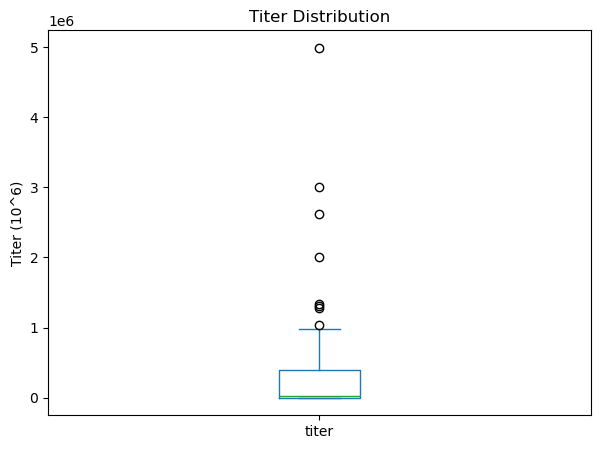

In [119]:
df_clean['titer'].plot(kind='box', figsize=(7,5)) #Creates a box plot with a certain size
plt.title("Titer Distribution") #Creates title for box plot
plt.ylabel("Titer (10^6)") #Labels the Y-axis of boxplot
plt.show() #Shows the boxplot

This boxplot shows that the median and lower quartile of the titer for the dataset are equal to 0. This indicates that most samples of the dataset have a zero titer, and that the higher titers are considered outliers instead. This goes against the hypothesis that the vomit might be a potential transmission source of the Norovirus.

### Barplot for the number of Samples for Each Study

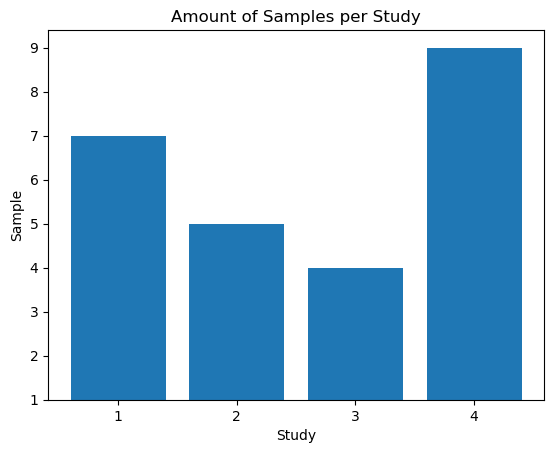

In [239]:
plt.bar(df_clean['Study'], df_clean['Sample']) #Creates a Study vs Sample var graph
plt.xlabel('Study') #Provides a label for the x-axis
plt.ylabel('Sample') #Provides a label for the y-axis
plt.title('Amount of Samples per Study') #Provides the title for the graph
plt.show() #Shows the graph

Here, it shows that the majority of the samples belong in the fourth study. Therefore, the dataset would be heavily influenced by the data in Study 4. Therefore, a new boxplot should be formed to avoid the data from Study 4 overshadowing the rest.

### Boxplot for titer in each Study

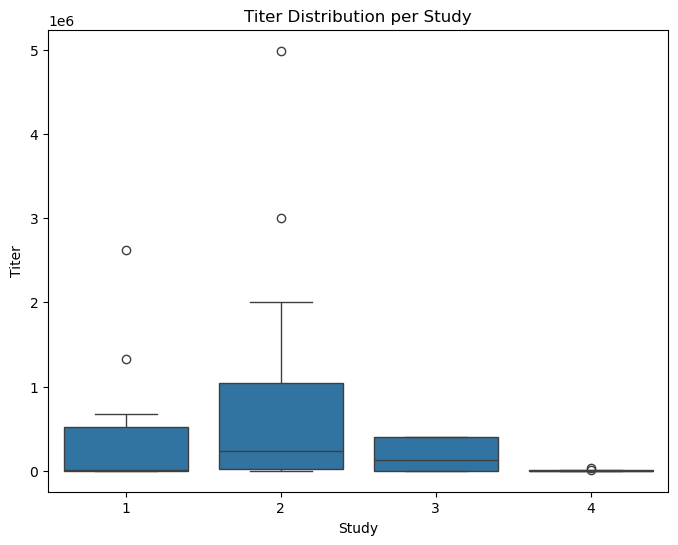

In [233]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x=df_clean['Study'], y=df_clean['titer']) #Creates a Titer boxplot that is seperated by study

plt.title('Titer Distribution per Study') #Provides title for boxplot
plt.xlabel('Study') #Provides a label for the x-axis
plt.ylabel('Titer') #Provides a label for the y-axis
plt.show() #Shows boxplot

Here, we see a more accurate titer distribution of the dataset by separating the boxplots by the Study. Here, we learned that the majority of the non-detectable titers were coming from the fourth study. Therefore, they may be experimental conditions in the fourth study that would heavily reduce the viral concentration in that study. Study 2 has the highest variation out of all the studies, and its outliers have higher values. Study 4 has the least amount of outliers, and most of its titers are zeros/non-detectable. Study 3 has no outliers with a spread of less than two. Study 1 also has less spread than Study 2. It also has two outliers, but they are lower than the outliers in study 2. Studies 1,2, and 3 contain more diverse and variable data. However, this is not reflected in the entire dataset. Since Study 4 contains more data, it has a heavy influence on the entire dataset. 

### 2. Use .groupby() and visualization to compare across categories:
* A bar plot or line plot comparing average or total values across categories.

## Finding the Optimal pH by Creating a Line Plot

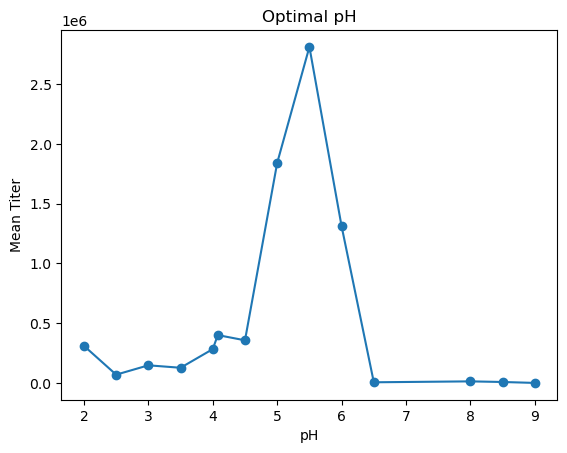

In [213]:
mean_titer= df_clean.groupby('pH')['titer'].mean() #Groups pH by the mean of the titer
plt.plot(mean_titer, marker='o') #This creates a linplot of the grouped variables with datapoint bullets
plt.xlabel('pH') #Labels the X-axis
plt.ylabel('Mean Titer') #Labels the y-axis
plt.title('Optimal pH') #Provides a title for graph
plt.show() #Shows graph

Here, we can see that there is an optimal pH value that results in the highest amount of titer. The optimal pH is between the range of 5-6. This is an interesting finding that indicates that the Norovirus thrives in vomit with a slight acidity despite being able to surive extreme conditions. 

## SECTION II: RELATIONSHIP VISUALIZATIONS (10 POINTS)
Use visualizations that reveal relationships between two numerical or mixed variables:
* A scatter plot.
* A heatmap of correlations.

### Visualization of Volume Using Correlation Matrix
* Here, a heatmap was generated to create a figure that shows all the correlations between all figures
* Scatterplots would be made out of a few variable pairs to further explore their correlation

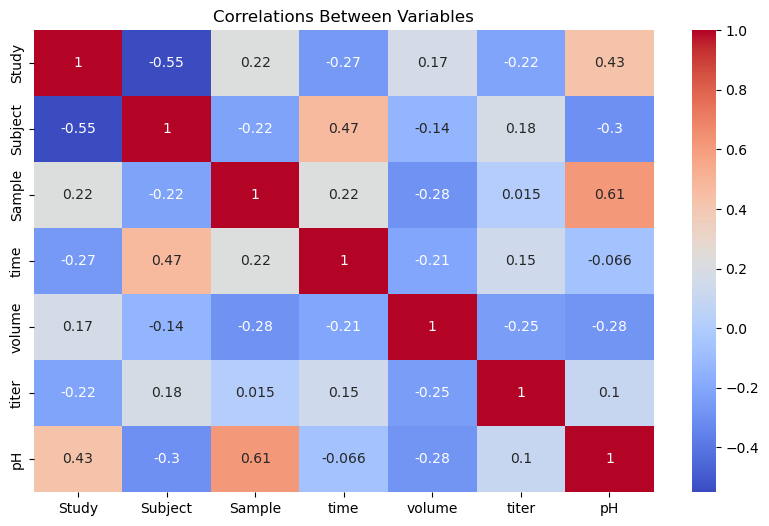

In [291]:
plt.figure(figsize=(10,6)) #Customizes the size of the heatmap
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm') #creates heatmap using the data from df_clean
plt.title("Correlations Between Variables") #Creates title for the heat map
plt.show() #Shows heatmap

Volume has a negative correlation with all numerical data. Therefore, when volume increases, the pH and titer decrease. The titer and pH have a weak correlation, so my hypothesis that they may affect each other was wrong. pH has a strong positive correlation with both the study and the sample. Study and Subjects also have a strong correlation. However, correlations that involve categorical data (Study, Subject, Sample) do not make sense because the numbers are used for organizational labeling. Therefore, there can not be an "increase" for these columns. 

### Scatterplot for the volume and pH

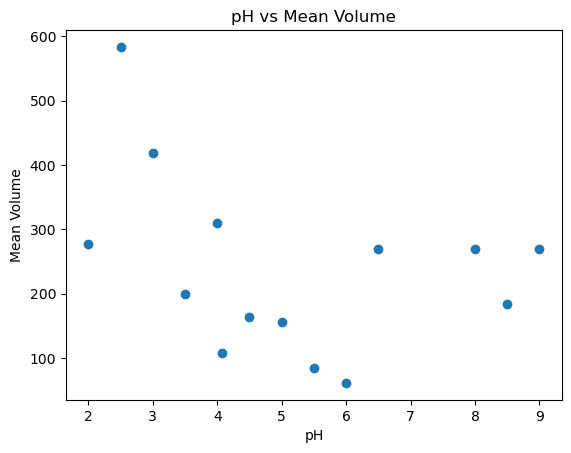

In [228]:
volume_pH = df_clean.groupby('pH')['volume'].mean() #Groups the pH by the mean of the volume
plt.scatter(volume_pH.index, volume_pH, marker='o') #Creates a scatterplot using the pH as the x-axis and the grouping as the y-axis
plt.xlabel('pH') #Labels the x-axis
plt.ylabel('Mean Volume') #Labels the y-axis
plt.title('pH vs Mean Volume') #Creates the title for the scatterplot
plt.show() #Shows the scatterplot

The pH and the mean Volume have a negative correlation. Therefore, the lower the pH, the higher the amount of vomit that would be produced. So, high acidity increases the volume of vomit. How is this possible, if the volume also has a negative correlation with the titer? If the titer thrives in less acidic (but not basic) conditions. Wouldn't the scatterplot also show this? This claim must be proven with another scatterplot.

### Scatterplot for volume and Titer
* Facet Grid was used to sperate the scatterplot data by the Study and prevent the influence of the fourth study (almost all zeros) on the entire dataset

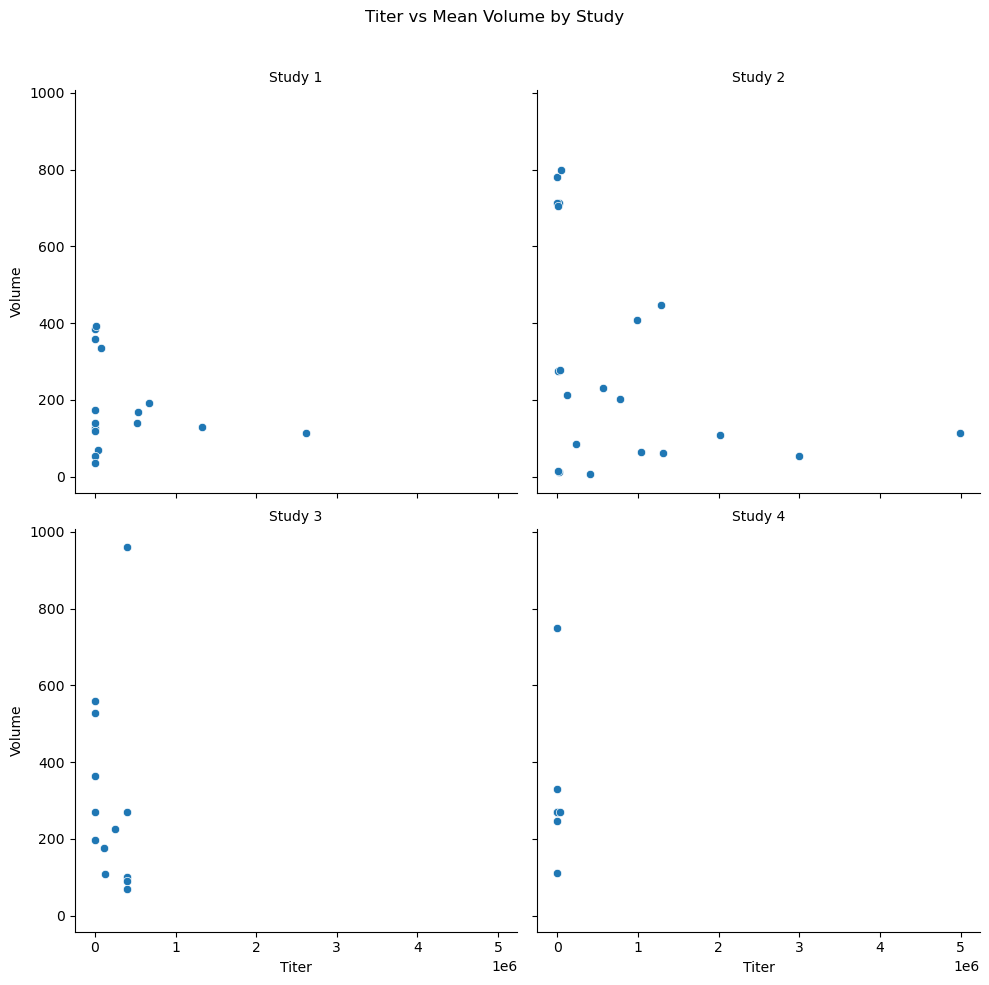

In [223]:
g = sns.FacetGrid(df_clean, col="Study", col_wrap=2, height=5) #This creates the outer part of the graph. It labels each minigraph as the Study. It also divides the graph into two columns and decides the size of graph.
g.map_dataframe(sns.scatterplot, x='titer', y='volume') #Creates the scatterplot for each study
g.set_axis_labels("Titer", "Volume") #Lebels the scatterplots x and y axis
g.set_titles(col_template="Study {col_name}") #Creates the title for each scatterplot
plt.subplots_adjust(top= 0.9) #Creates space between the facet grid and title
g.fig.suptitle("Titer vs Mean Volume by Study") #Creates the title for the entire grid
plt.show() #Shows facet grid

In the map, I understand why the heatmap indicates that the titer and volume have a slight negative correlation. However, the majority of the datapoint clusters form a vertical line. If we ignore the outliers of the data, we can confirm that there is no correlation at all between the titer and volume. This makes sense because a lower pH (2-3) creates a higher volume of vomit. But a slightly higher pH (5-6) creates a higher titer. If these two statements are true, then the volume and titer can not correlate. Therefore, pH is the only variable that has an affect of the titer.